**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 01. Probability Distributions in Numerics
This notebook provides a comprehensive tour of the 42+ probability distributions available in Numerics.

## What You'll Learn

- Creating and parameterizing distributions
- Computing PDF, CDF, and quantiles
- Statistical properties (mean, variance, skewness, kurtosis)
- When to use each distribution
- Generating random samples

## Setup

In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load Numerics DLL (modify path as needed)
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

# Import commonly used distributions
from Numerics.Distributions import (
    Normal, LogNormal, Uniform, Triangular,
    GammaDistribution, Weibull, GeneralizedExtremeValue, Poisson, Binomial, Pert
)
from Numerics.Sampling import LatinHypercube 

print("✓ Setup complete")

✓ Setup complete


## Basic Example
Recall the basic example we started in notebook 00 with the Normal distribution. We will return to that to compute the CDF, PDF, and quantiles.

### Normal Distribution

**When to use:** Symmetric data, many natural phenomena, Central Limit Theorem applications

**Parameters:** μ (mean), σ (standard deviation)

Mean: 100.0
Standard Deviation: 15.0
Variance: 225.0
Skewness: 0.0
Kurtosis: 3.0
Minimum: -inf
Maximum: inf
5th Percentile: 75.32719559572791
Median: 100.0
95th Percentile: 124.67280440427207


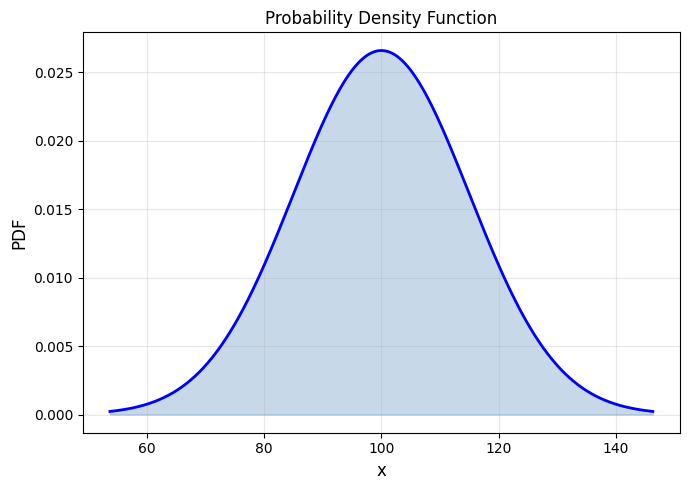

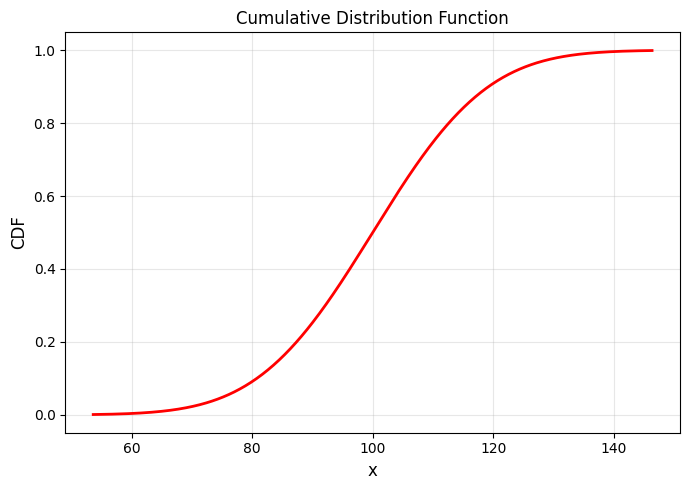

In [2]:
## Create Normal distribution -- Normal(mean=100, stddev=15)
normal = Normal(100, 15)

## Get statistical properties
print(f"Mean: {normal.Mean}")
print(f"Standard Deviation: {normal.StandardDeviation}")
print(f"Variance: {normal.Variance}")
print(f"Skewness: {normal.Skewness}")
print(f"Kurtosis: {normal.Kurtosis}")
print(f"Minimum: {normal.Minimum}")
print(f"Maximum: {normal.Maximum}")
print(f"5th Percentile: {normal.InverseCDF(0.05)}")
print(f"Median: {normal.InverseCDF(0.5)}")
print(f"95th Percentile: {normal.InverseCDF(0.95)}")

## Plotting
# Define range for x values using 0.1% to 99.9% quantiles
x_min = normal.InverseCDF(0.001)
x_max = normal.InverseCDF(0.999)
x = np.linspace(x_min, x_max, 500)

# Compute PDF and CDF values
pdf = [normal.PDF(xi) for xi in x]
cdf = [normal.CDF(xi) for xi in x]

# PDF plot
plt.figure(figsize=(7, 5))
ax1 = plt.gca() 
# !! The line below is the most important, everything else is just formatting to make it pretty!!
ax1.plot(x, pdf, 'b-', linewidth=2) 
ax1.fill_between(x, pdf, alpha=0.3, color='steelblue')
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('PDF', fontsize=12)
ax1.set_title('Probability Density Function', fontsize=12)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# CDF plot
plt.figure(figsize=(7, 5))
ax2 = plt.gca()
# !! The line below is the most important, everything else is just formatting to make it pretty!!
ax2.plot(x, cdf, 'r-', linewidth=2)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('CDF', fontsize=12)
ax2.set_title('Cumulative Distribution Function', fontsize=12)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## Helper Functions
We use some helper functions in this notebook to make exploring our distributions easier. Everything in these functions is covered in our example above, just now in a nice reusable package.

In [3]:
def plot_distribution(dist, x_range=None, n_points=500, title=None):
    """Plot PDF and CDF of a distribution."""
    if x_range is None:
        x_min = dist.InverseCDF(0.001)
        x_max = dist.InverseCDF(0.999)
    else:
        x_min, x_max = x_range
    
    x = np.linspace(x_min, x_max, n_points)
    pdf = [dist.PDF(xi) for xi in x]
    cdf = [dist.CDF(xi) for xi in x]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(x, pdf, 'b-', linewidth=2)
    ax1.fill_between(x, pdf, alpha=0.3, color='steelblue')
    ax1.set_xlabel('x', fontsize=12)
    ax1.set_ylabel('PDF', fontsize=12)
    ax1.set_title('Probability Density Function', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(x, cdf, 'r-', linewidth=2)
    ax2.set_xlabel('x', fontsize=12)
    ax2.set_ylabel('CDF', fontsize=12)
    ax2.set_title('Cumulative Distribution Function', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()

def print_statistics(dist, name="Distribution"):
    """Display key statistics of a distribution as a formatted table."""
    stats_df = pd.DataFrame({
        'Statistic': ['Mean','Std Deviation','Variance','Skewness','Kurtosis','Minimum','Maximum','5th Percentile','Median','95th Percentile'],
        'Value': [dist.Mean,dist.StandardDeviation,dist.Variance,dist.Skewness,dist.Kurtosis,dist.Minimum,dist.Maximum,dist.InverseCDF(0.05),dist.InverseCDF(0.5),dist.InverseCDF(0.95)]
    })
    print(f"\n{name} Statistics:")
    display(stats_df.round(4))


## 1. Continuous Distributions
**Parameterization note:** Numerics uses its own parameter conventions (e.g., GEV uses ξ, α, κ). If you’re comparing to textbooks or SciPy, double‑check parameter definitions.

### Log-Normal Distribution

**When to use:** Right-skewed data that's always positive (income, particle sizes, stock prices)

**Parameters:** μ (log-space mean), σ (log-space std dev)


LogNormal(4.0, 0.5) Statistics:


,Statistic,Value
0,Mean,1.940096e+04
1,Std Deviation,3.225447e+04
2,Variance,1.040351e+09
3,Skewness,9.582700e+00
4,Kurtosis,3.468718e+02
5,Minimum,0.000000e+00
6,Maximum,inf
7,5th Percentile,1.505127e+03
8,Median,1.000000e+04
9,95th Percentile,6.643957e+04


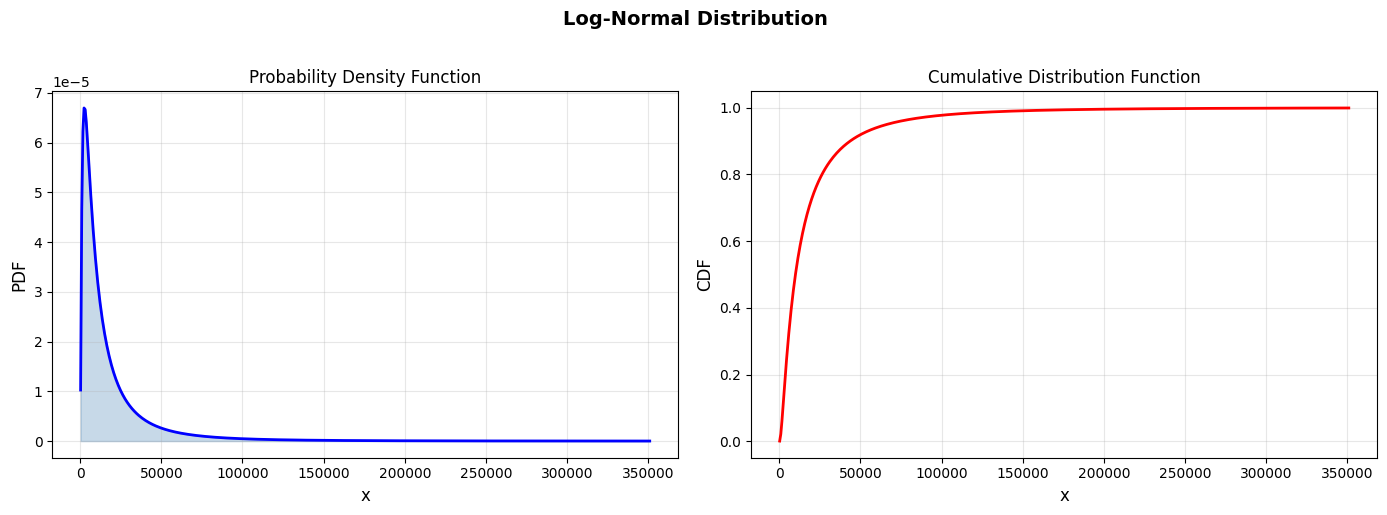

In [4]:
lognormal = LogNormal(4.0, 0.5)

print_statistics(lognormal, "LogNormal(4.0, 0.5)")
plot_distribution(lognormal, title="Log-Normal Distribution")

### Generalized Extreme Value (GEV)

**When to use:** Modeling extreme events (floods, droughts, maximum/minimum values)

**Parameters:** ξ (location), α (scale), κ (shape)

- κ < 0: Weibull (bounded above)
- κ = 0: Gumbel (unbounded)
- κ > 0: Fréchet (heavy-tailed)

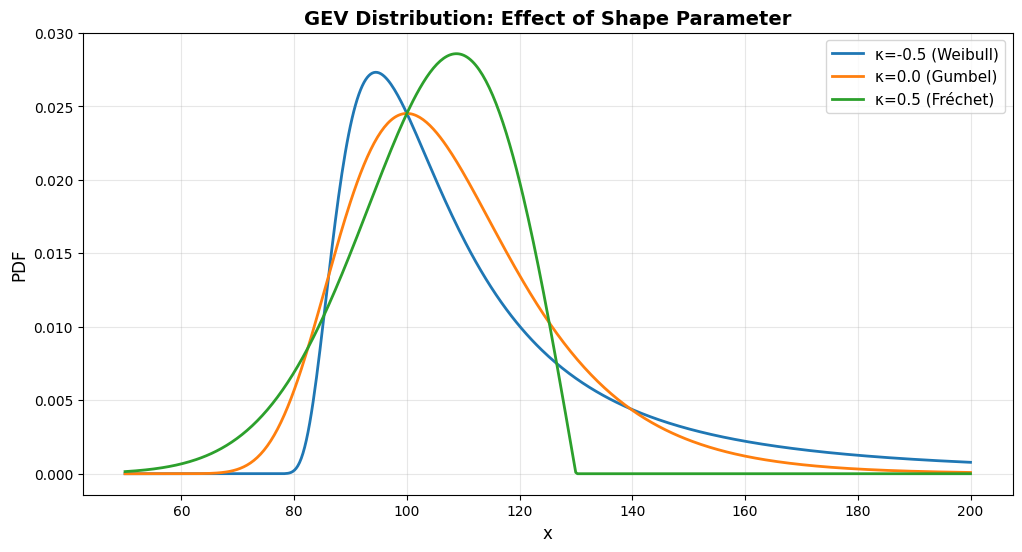


GEV (Fréchet type) Statistics:


,Statistic,Value
0,Mean,103.4132
1,Std Deviation,NaN
2,Variance,NaN
3,Skewness,NaN
4,Kurtosis,NaN
5,Minimum,-inf
6,Maximum,130.0000
7,5th Percentile,78.0754
8,Median,105.0234
9,95th Percentile,123.2056



GEV (Gumbel type) Statistics:


,Statistic,Value
0,Mean,108.6582
1,Std Deviation,19.2382
2,Variance,370.1102
3,Skewness,1.1396
4,Kurtosis,5.4000
5,Minimum,-inf
6,Maximum,inf
7,5th Percentile,83.5422
8,Median,105.4977
9,95th Percentile,144.5529



GEV (Weibull type) Statistics:


,Statistic,Value
0,Mean,123.1736
1,Std Deviation,NaN
2,Variance,NaN
3,Skewness,NaN
4,Kurtosis,NaN
5,Minimum,70.0000
6,Maximum,inf
7,5th Percentile,87.3328
8,Median,106.0337
9,95th Percentile,202.4619


In [5]:
# Create GEV distributions with different shapes
gev_weibull = GeneralizedExtremeValue(100, 15, -0.5)
gev_gumbel = GeneralizedExtremeValue(100, 15, 0.0)
gev_frechet = GeneralizedExtremeValue(100, 15, 0.5)

# Compare shapes
x = np.linspace(50, 200, 500)
plt.figure(figsize=(12, 6))
plt.plot(x, [gev_weibull.PDF(xi) for xi in x], label='κ=-0.5 (Weibull)', linewidth=2)
plt.plot(x, [gev_gumbel.PDF(xi) for xi in x], label='κ=0.0 (Gumbel)', linewidth=2)
plt.plot(x, [gev_frechet.PDF(xi) for xi in x], label='κ=0.5 (Fréchet)', linewidth=2)
plt.xlabel('x', fontsize=12)
plt.ylabel('PDF', fontsize=12)
plt.title('GEV Distribution: Effect of Shape Parameter', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print_statistics(gev_frechet, "GEV (Fréchet type)")
print_statistics(gev_gumbel, "GEV (Gumbel type)")
print_statistics(gev_weibull, "GEV (Weibull type)")

### Gamma and Weibull

**Gamma:** Positive data, waiting times, rainfall amounts  

**Parameters:** θ (scale), κ (shape)


**Weibull:** Reliability analysis, wind speeds, failure times 

**Parameters:** λ (scale), κ (shape)


Gamma(θ=2, κ=0.5) Statistics:


,Statistic,Value
0,Mean,1.0000
1,Std Deviation,1.4142
2,Variance,2.0000
3,Skewness,2.8284
4,Kurtosis,15.0000
5,Minimum,0.0000
6,Maximum,inf
7,5th Percentile,0.0039
8,Median,0.4549
9,95th Percentile,3.8415


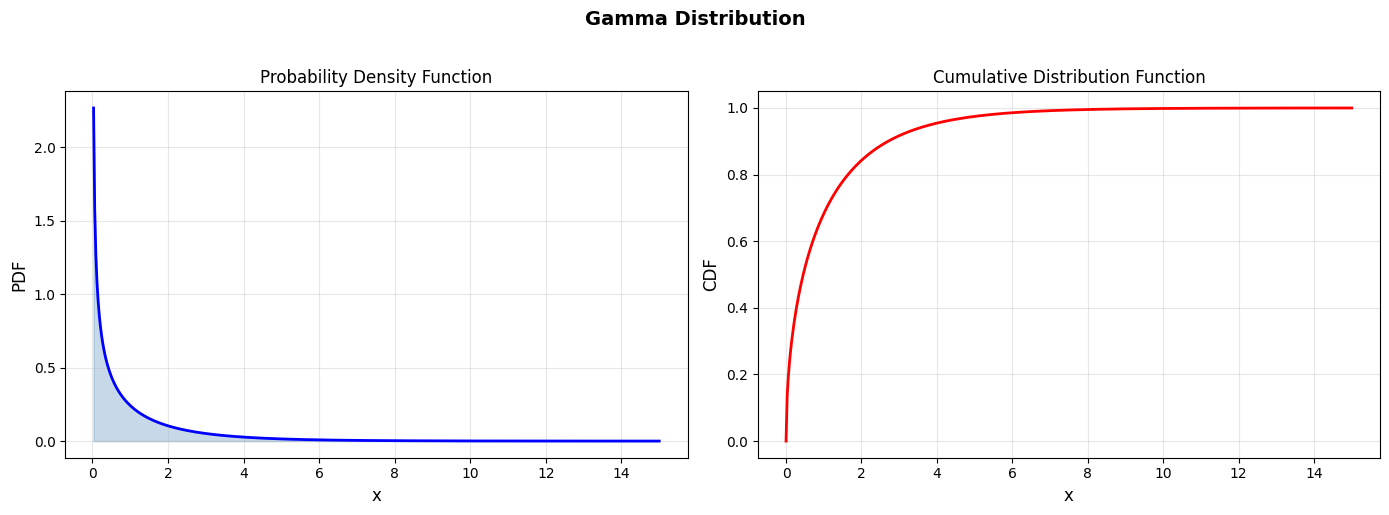


Weibull(λ=100, κ=2.5) Statistics:


,Statistic,Value
0,Mean,88.7264
1,Std Deviation,37.9667
2,Variance,1441.4669
3,Skewness,0.3586
4,Kurtosis,2.8568
5,Minimum,0.0000
6,Maximum,inf
7,5th Percentile,30.4807
8,Median,86.3635
9,95th Percentile,155.0962


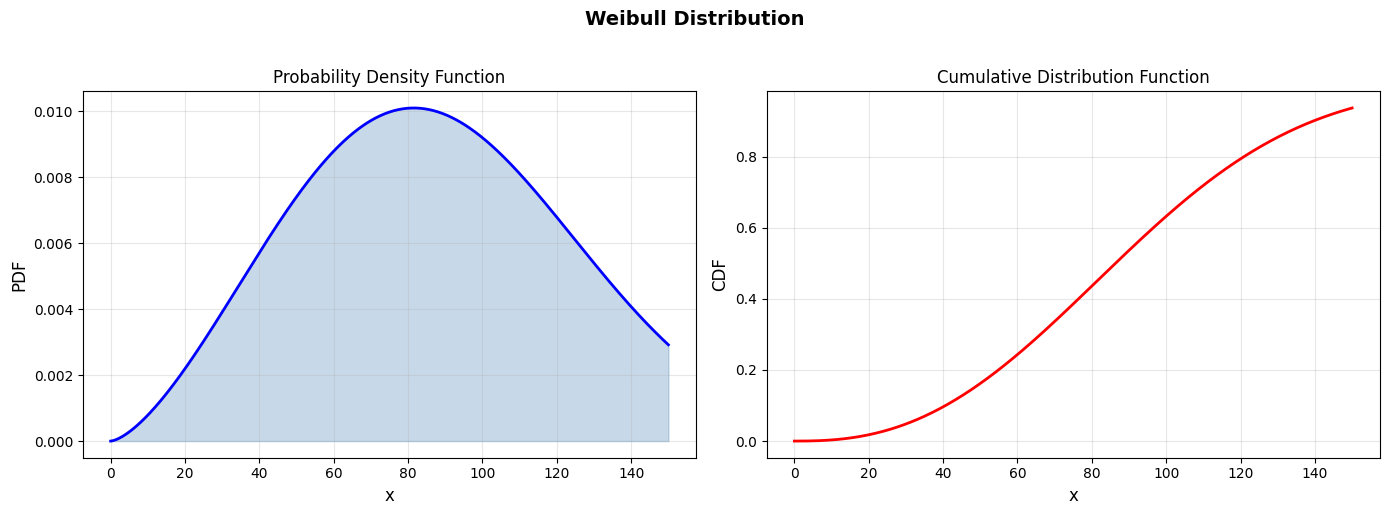

In [6]:
# Gamma distribution
gamma = GammaDistribution(2.0, 0.5)
print_statistics(gamma, "Gamma(θ=2, κ=0.5)")
plot_distribution(gamma, x_range=(0, 15), title="Gamma Distribution")

# Weibull distribution
weibull = Weibull(100, 2.5)
print_statistics(weibull, "Weibull(λ=100, κ=2.5)")
plot_distribution(weibull, x_range=(0, 150), title="Weibull Distribution")

### Uniform and Triangular

**Uniform:** Bounded data with no preference for any value  

**Parameters:** min, max


**Triangular:** Bounded data with a most likely value (expert opinion)

**Parameters:** min, mode, max


Uniform(0, 100) Statistics:


,Statistic,Value
0,Mean,50.0000
1,Std Deviation,28.8675
2,Variance,833.3333
3,Skewness,0.0000
4,Kurtosis,1.8000
5,Minimum,0.0000
6,Maximum,100.0000
7,5th Percentile,5.0000
8,Median,50.0000
9,95th Percentile,95.0000


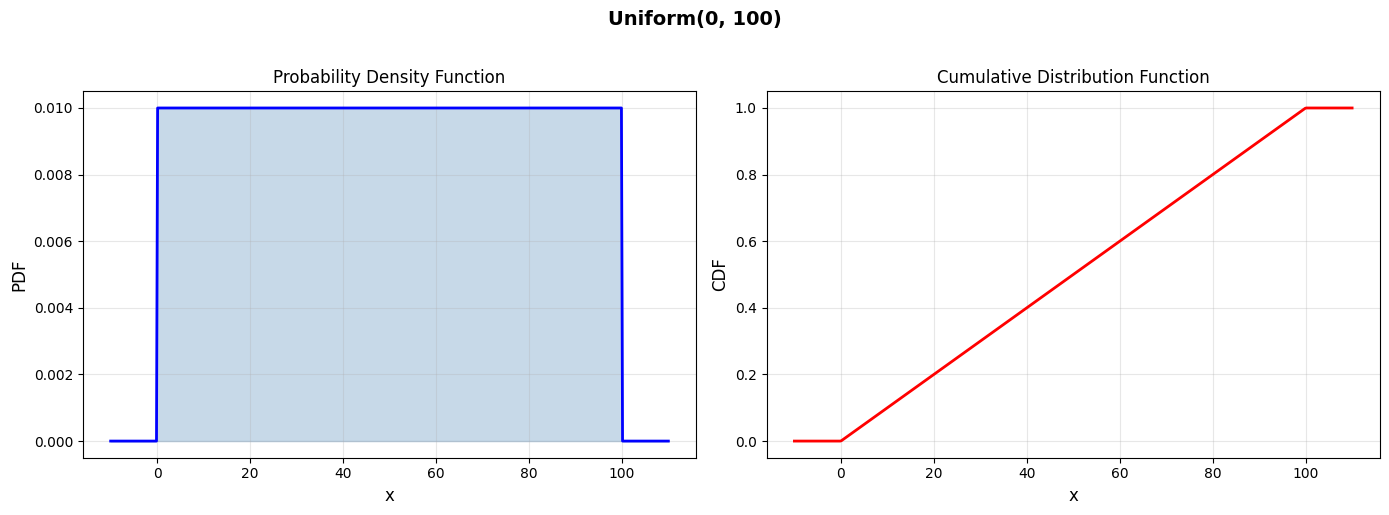


Triangular(0, 30, 100) Statistics:


,Statistic,Value
0,Mean,43.3333
1,Std Deviation,20.9497
2,Variance,438.8889
3,Skewness,0.3561
4,Kurtosis,2.4000
5,Minimum,0.0000
6,Maximum,100.0000
7,5th Percentile,12.2474
8,Median,40.8392
9,95th Percentile,81.2917


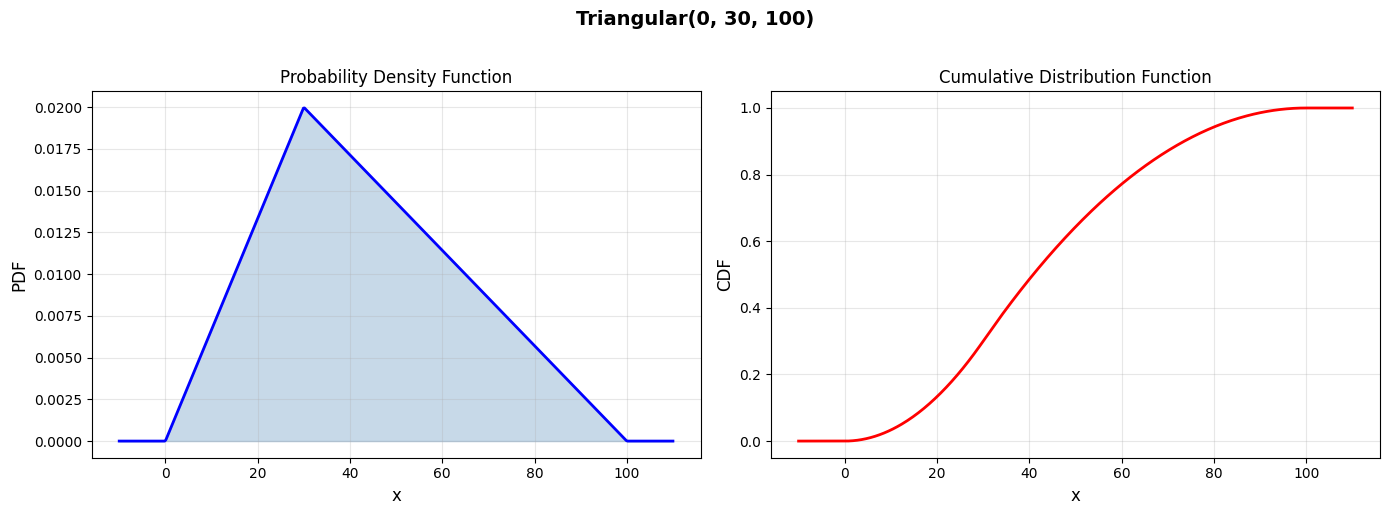

In [7]:
# Uniform distribution
uniform = Uniform(0, 100)
print_statistics(uniform, "Uniform(0, 100)")
plot_distribution(uniform, x_range=(-10, 110), title="Uniform(0, 100)")

# Triangular distribution
triangular = Triangular(0, 30, 100)
print_statistics(triangular, "Triangular(0, 30, 100)")
plot_distribution(triangular, x_range=(-10, 110), title="Triangular(0, 30, 100)")

### PERT Distribution

**When to use:** Project planning, expert elicitation (smoother than Triangular)

**Parameters:** min, mode, max


PERT(10, 50, 100) Statistics:


,Statistic,Value
0,Mean,51.6667
1,Std Deviation,16.9617
2,Variance,287.6984
3,Skewness,0.0983
4,Kurtosis,2.3462
5,Minimum,10.0000
6,Maximum,100.0000
7,5th Percentile,24.4643
8,Median,51.2732
9,95th Percentile,80.2234


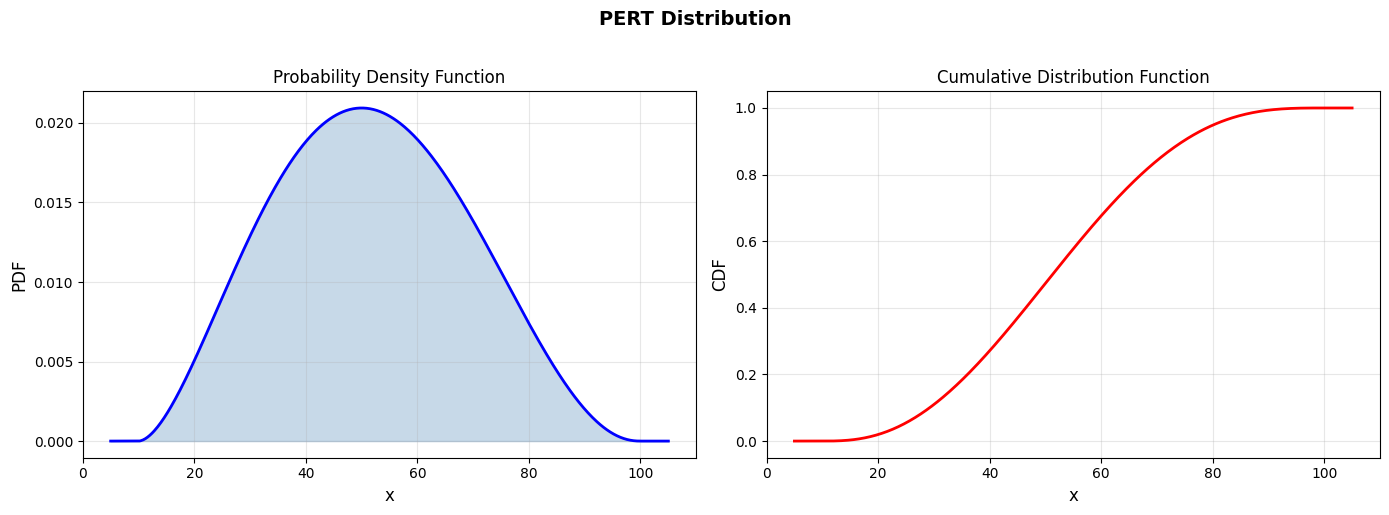

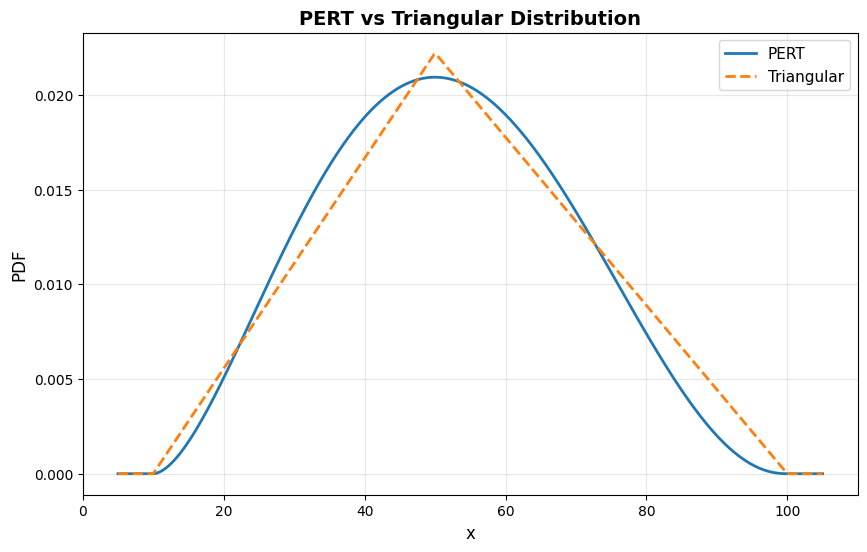

In [8]:
# PERT distribution (smoother version of Triangular)
pert = Pert(10, 50, 100)
print_statistics(pert, "PERT(10, 50, 100)")
plot_distribution(pert, x_range=(5, 105), title="PERT Distribution")

# Compare PERT vs Triangular
tri = Triangular(10, 50, 100)
x = np.linspace(5, 105, 500)
plt.figure(figsize=(10, 6))
plt.plot(x, [pert.PDF(xi) for xi in x], label='PERT', linewidth=2)
plt.plot(x, [tri.PDF(xi) for xi in x], label='Triangular', linewidth=2, linestyle='--')
plt.xlabel('x', fontsize=12)
plt.ylabel('PDF', fontsize=12)
plt.title('PERT vs Triangular Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

## 2. Discrete Distributions
**Note:** Numerics uses `PDF()` for both continuous and discrete distributions. For discrete distributions, interpret `PDF()` as the PMF.

### Poisson Distribution

**When to use:** Count data, events per time period, rare events

**Parameters:** λ (rate)

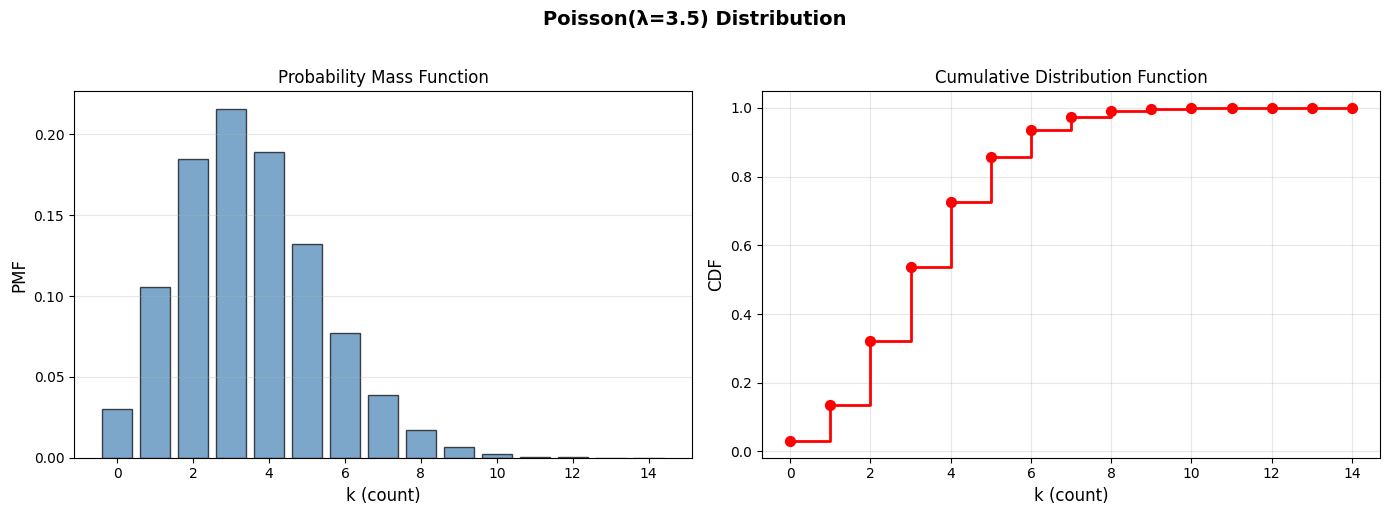

Mean: 3.50
Variance: 3.50
P(X = 3): 0.2158
P(X ≤ 5): 0.8576


In [9]:
# Poisson distribution
poisson = Poisson(3.5)

# For discrete distributions, plot PMF instead of PDF
k = np.arange(0, 15)
# Convert to float for compatibility
pmf = [poisson.PDF(float(ki)) for ki in k]  # PDF method works for both continuous and discrete
cdf = [poisson.CDF(float(ki)) for ki in k]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(k, pmf, alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_xlabel('k (count)', fontsize=12)
ax1.set_ylabel('PMF', fontsize=12)
ax1.set_title('Probability Mass Function', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')

ax2.step(k, cdf, where='post', linewidth=2, color='red')
ax2.scatter(k, cdf, color='red', s=50, zorder=3)
ax2.set_xlabel('k (count)', fontsize=12)
ax2.set_ylabel('CDF', fontsize=12)
ax2.set_title('Cumulative Distribution Function', fontsize=12)
ax2.grid(True, alpha=0.3)

fig.suptitle('Poisson(λ=3.5) Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Mean: {poisson.Mean:.2f}")
print(f"Variance: {poisson.Variance:.2f}")
print(f"P(X = 3): {poisson.PDF(3):.4f}")
print(f"P(X ≤ 5): {poisson.CDF(5):.4f}")

### Binomial Distribution

**When to use:** Fixed number of trials, binary outcomes (success/failure)

**Parameters:** p (success probability), n (number of trials)

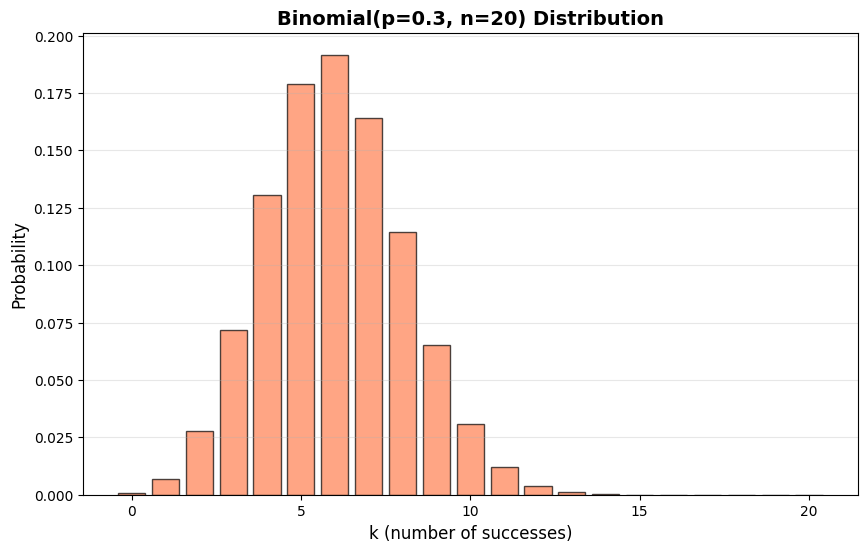

Expected value: 6.00
Most likely value: 6


In [10]:
# Binomial distribution (p=0.3 success probability, n=20 trials)
binomial = Binomial(0.3, 20)

k = np.arange(0, 21)
# Convert to float for compatibility
pmf = [binomial.PDF(float(ki)) for ki in k]

plt.figure(figsize=(10, 6))
plt.bar(k, pmf, alpha=0.7, color='coral', edgecolor='black')
plt.xlabel('k (number of successes)', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Binomial(p=0.3, n=20) Distribution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

print(f"Expected value: {binomial.Mean:.2f}")
print(f"Most likely value: {int(binomial.Mean)}")

## 3. Generating and Analyzing Random Samples

Our univariate distributions (i.e. all the ones in this notebook) have a built in method for generating random samples, GenerateRandomValues(). We use this method below for the Normal, LogNormal, and Gamma Distributions.

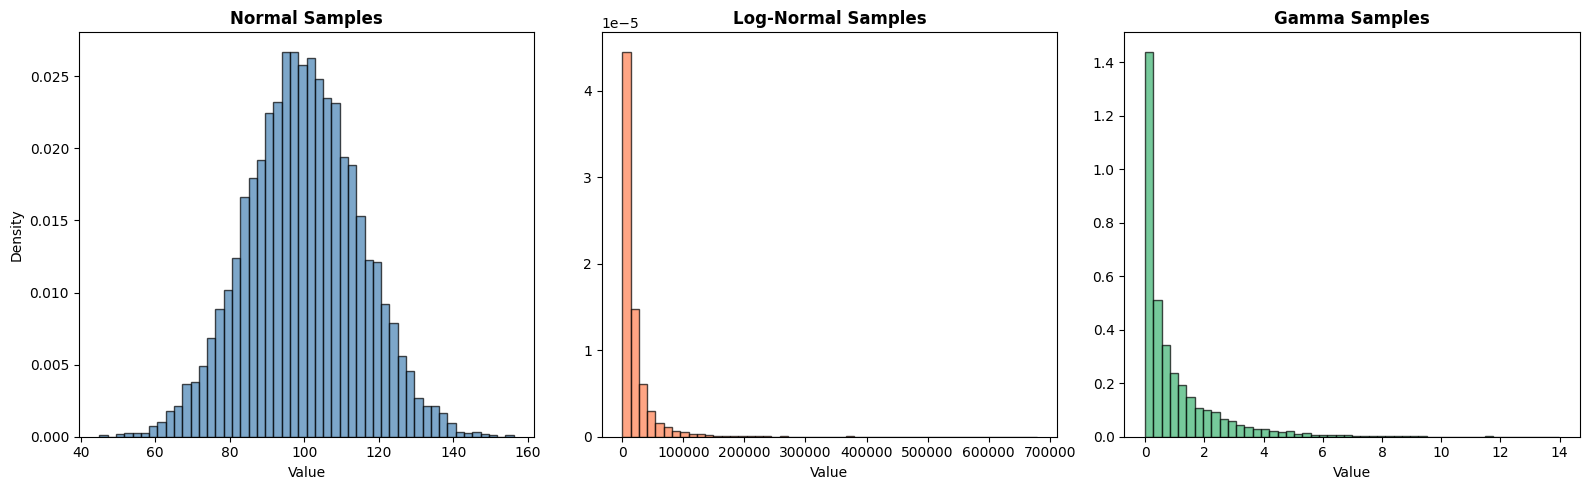


Sample Statistics:


,Distribution,Sample Mean,Sample Std,Sample Skew
0,Normal,99.831721,15.094639,0.030557
1,Log-Normal,19653.957077,31444.247098,6.044928
2,Gamma,0.993101,1.370375,2.614301


In [11]:
# Generate samples from different distributions
n_samples = 10000

normal_samples = list(Normal(100, 15).GenerateRandomValues(n_samples))
lognormal_samples = list(LogNormal(4, 0.5).GenerateRandomValues(n_samples))
gamma_samples = list(GammaDistribution(2, 0.5).GenerateRandomValues(n_samples))

# Create comparison plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(normal_samples, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_title('Normal Samples', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')

axes[1].hist(lognormal_samples, bins=50, density=True, alpha=0.7, color='coral', edgecolor='black')
axes[1].set_title('Log-Normal Samples', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Value')

axes[2].hist(gamma_samples, bins=50, density=True, alpha=0.7, color='mediumseagreen', edgecolor='black')
axes[2].set_title('Gamma Samples', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Value')

plt.tight_layout()
plt.show()

# Summary statistics
stats_df = pd.DataFrame({
    'Distribution': ['Normal', 'Log-Normal', 'Gamma'],
    'Sample Mean': [np.mean(normal_samples), np.mean(lognormal_samples), np.mean(gamma_samples)],
    'Sample Std': [np.std(normal_samples), np.std(lognormal_samples), np.std(gamma_samples)],
    'Sample Skew': [
        pd.Series(normal_samples).skew(),
        pd.Series(lognormal_samples).skew(),
        pd.Series(gamma_samples).skew()
    ]
})

print("\nSample Statistics:")
display(stats_df)


### Latin Hypercube Sampling
Latin Hypercube Sampling (LHS) is a stratified sampling technique that ensures each dimension is sampled evenly.
This produces better space-filling designs than pure random sampling when the number of samples is limited.


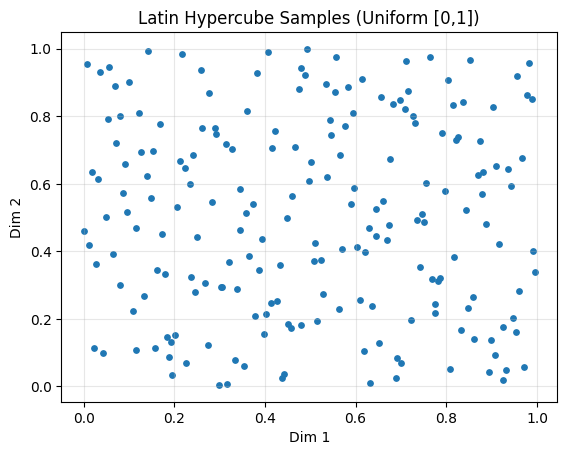

In [12]:
# LHS in [0,1] for each dimension
n_samples = 200
dim = 2
lhs = LatinHypercube.Random(n_samples, dim, seed=12345)

# Convert to numpy for plotting
lhs_np = np.array([[lhs[i, j] for j in range(dim)] for i in range(n_samples)])

plt.scatter(lhs_np[:, 0], lhs_np[:, 1], s=15)
plt.title("Latin Hypercube Samples (Uniform [0,1])")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True, alpha=0.3)
plt.show()

## 4. Distribution Selection Guide

|Distribution|Type|Typical Use Case|Parameters|
|---|---|---|---|
|Normal|Continuous|Symmetric data, measurements|μ, σ|
|Log-Normal|Continuous|Right-skewed positive data|μ, σ|
|Uniform|Continuous|Equal probability over range|min, max|
|Triangular|Continuous|Bounded with mode|min, mode, max|
|PERT|Continuous|Project estimates|min, mode, max|
|Gamma|Continuous|Positive data, waiting times|θ, κ|
|Weibull|Continuous|Reliability, failure time|λ, κ|
|Gumbel|Continuous|Extreme maxima|ξ,α|
|GEV|Continuous|General extreme values|ξ, α, κ|
|Exponential|Continuous|Time between events|λ|
|Poisson|Discrete|Count data, rare events|λ|
|Binomial|Discrete|Binary outcomes, trials|n, p|



## 5. Advanced: Comparing Multiple Distributions

Let's compare distributions that might be candidates for the same dataset.

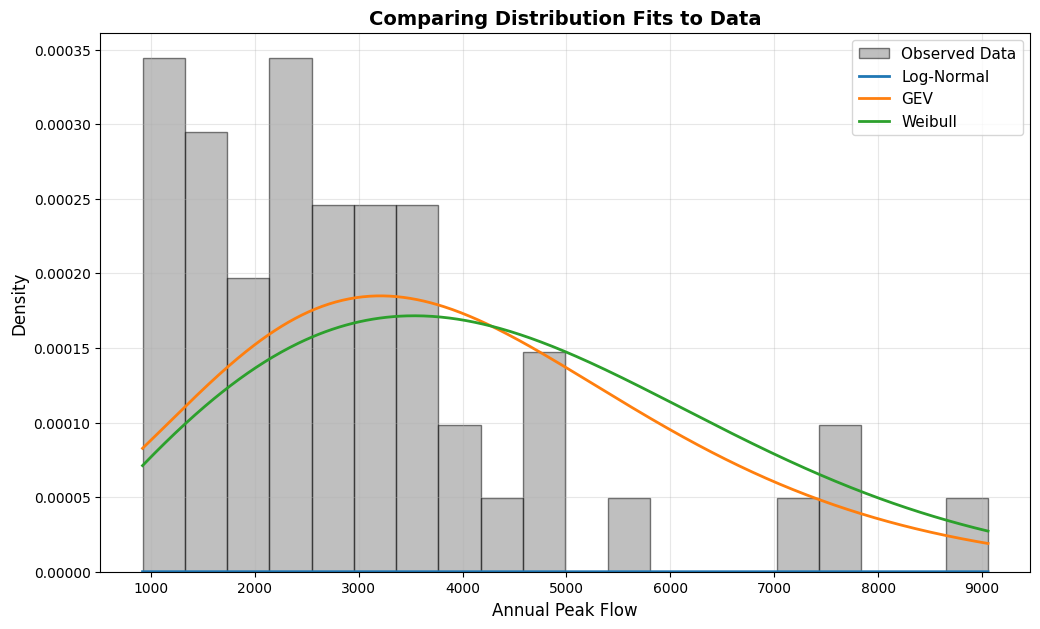


Note: These are illustrative parameters. See notebook 02 for formal fitting.


In [13]:
# Simulate flood frequency data
np.random.seed(42)
observed_data = np.random.lognormal(mean=8, sigma=0.6, size=50)

# Use sample moments to set an illustrative LogNormal fit for this quick comparison.
lognormal_fit = LogNormal(np.mean(observed_data), np.std(observed_data, ddof=1))
gev_fit = GeneralizedExtremeValue(3000, 2000, 0.1)
weibull_fit = Weibull(5000, 2.0)

# Plot comparison
plt.figure(figsize=(12, 7))

# Histogram of observed data
plt.hist(observed_data, bins=20, density=True, alpha=0.5, color='gray', edgecolor='black', label='Observed Data')

# Overlay candidate distributions
x = np.linspace(min(observed_data), max(observed_data), 500)
plt.plot(x, [lognormal_fit.PDF(xi) for xi in x], linewidth=2, label='Log-Normal')
plt.plot(x, [gev_fit.PDF(xi) for xi in x], linewidth=2, label='GEV')
plt.plot(x, [weibull_fit.PDF(xi) for xi in x], linewidth=2, label='Weibull')

plt.xlabel('Annual Peak Flow', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Comparing Distribution Fits to Data', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("\nNote: These are illustrative parameters. See notebook 02 for formal fitting.")


## Summary
You've now explored:    

✓ Creating distributions with different parameters     
✓ Computing PDF, CDF, and quantiles    
✓  Generating random samples   
✓  Visualizing distributions   
✓ Understanding when to use each distribution  


## Next Steps

- **02_distribution_fitting.ipynb** - Learn how to fit distributions to your data using MLE, MOM, and L-Moments
- **03_mcmc_basics.ipynb** - Use distributions as priors in Bayesian inference

## Exercise

Try creating and plotting these distributions on your own:
1. Beta(2, 5) - useful for probabilities and proportions
2. Student-T(df=3) - heavy-tailed alternative to Normal
3. Chi-Squared(df=5) - goodness-of-fit testing